# Notebook 07 — Human Evaluation Analysis

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 4 (prep) / 8–9 (analysis)

**This notebook has two stages:**

**STAGE 1 (Run now — Week 4):** Select and export text samples for your Google Form.

**STAGE 2 (Run after Week 9):** Load Google Forms responses and produce human evaluation results.

**Study design:**  
13–14 participants each read 15 text samples and judge each as *Human-written* or *AI-generated*.  
Samples are drawn from 3 conditions (5 each):
- **Condition A:** Human-written text (from HC3 test set)
- **Condition B:** Original AI-generated text (before rewriting)
- **Condition C:** Rewritten AI text (after paraphrase attack)

> **DISSERTATION NOTE:** Human evaluation results go into Chapter 5 (Results) and Chapter 6 (Discussion).

---
# STAGE 1 — Prepare Samples for Google Form
## Run this now (Week 4) to generate your Google Form content
---

## Cell 1 — Imports and Paths

In [1]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
DATA_ADV        = os.path.join(PROJECT_ROOT, 'data', 'adversarial')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_TABLES  = os.path.join(PROJECT_ROOT, 'results', 'tables')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
HE_DIR          = os.path.join(PROJECT_ROOT, 'human_evaluation')

for d in [os.path.join(HE_DIR, 'form_screenshots'),
          os.path.join(HE_DIR, 'responses'),
          os.path.join(HE_DIR, 'analysis')]:
    os.makedirs(d, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Select 15 Samples for Google Form

We select:
- **5 human-written** samples from the test set (label=0)
- **5 original AI** samples (label=1, before rewriting)
- **5 rewritten AI** samples (after paraphrase attack)

All samples are truncated to 150 words to keep the form readable.

In [2]:
MAX_WORDS_FOR_FORM = 150   # keep samples short so participants can read quickly

def truncate(text, max_words=MAX_WORDS_FOR_FORM):
    words = str(text).split()
    if len(words) <= max_words:
        return text
    return ' '.join(words[:max_words]) + '...'


# ── Load test set ──────────────────────────────────────────────────────────────
test_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'test.csv'))

# 5 human samples
human_samples = (
    test_df[test_df['label'] == 0]
    .sample(5, random_state=RANDOM_SEED)['text']
    .apply(truncate)
    .tolist()
)

# ── Load adversarial set ───────────────────────────────────────────────────────
adv_df = pd.read_csv(os.path.join(DATA_ADV, 'pegasus_rewritten_500.csv'))
adv_df = adv_df[adv_df['success'] == True].reset_index(drop=True)

# 5 original AI samples (from the adversarial CSV — before rewriting)
sampled_adv = adv_df.sample(5, random_state=RANDOM_SEED)
original_ai_samples = sampled_adv['original_text'].apply(truncate).tolist()

# 5 rewritten AI samples (after rewriting) — same rows as above
rewritten_samples = sampled_adv['rewritten_text'].apply(truncate).tolist()


# ── Build the form sample list ─────────────────────────────────────────────────
form_samples = []
for i, text in enumerate(human_samples):
    form_samples.append({'sample_id': f'H{i+1}', 'condition': 'Human',        'text': text, 'true_label': 'Human'})
for i, text in enumerate(original_ai_samples):
    form_samples.append({'sample_id': f'A{i+1}', 'condition': 'Original AI',  'text': text, 'true_label': 'AI'})
for i, text in enumerate(rewritten_samples):
    form_samples.append({'sample_id': f'R{i+1}', 'condition': 'Rewritten AI', 'text': text, 'true_label': 'AI'})

# Shuffle so participants see mixed conditions
random.shuffle(form_samples)
for i, s in enumerate(form_samples):
    s['question_number'] = i + 1

form_df = pd.DataFrame(form_samples)

# Save the answer key (do NOT share this with participants)
answer_key_path = os.path.join(HE_DIR, 'analysis', 'answer_key.csv')
form_df.to_csv(answer_key_path, index=False)

print(f'15 samples selected and shuffled.')
print(f'Answer key saved to: {answer_key_path}')
print(f'\nSample distribution:')
print(form_df['condition'].value_counts().to_string())

15 samples selected and shuffled.
Answer key saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\human_evaluation\analysis\answer_key.csv

Sample distribution:
condition
Original AI     5
Rewritten AI    5
Human           5


## Cell 3 — Print All 15 Samples for Google Form

Copy each sample text into your Google Form as a question.

> **GOOGLE FORM SETUP INSTRUCTIONS:**
> 1. Go to forms.google.com → create a new blank form
> 2. Title: "AI vs Human Text Detection Study — UWS MSc Research"
> 3. Add a section with: brief instructions, consent statement
> 4. For each of the 15 samples below, add a Multiple Choice question:
>    - Question text: paste the sample text + "Who wrote this text?"
>    - Options: "Human-written" / "AI-generated"
> 5. At the end, add: "How confident were you overall? (1–5 scale)"
> 6. Collect responses via the Responses tab → link to Google Sheets
>
> **SCREENSHOT REMINDER:** Take a screenshot of your completed Google Form.  
> Save as: `screenshots/17_google_form.png`

In [3]:
print('=== SAMPLES TO PASTE INTO GOOGLE FORM ===')
print('Copy each sample exactly as shown below.')
print('The Question Number is what appears in the form (do NOT reveal condition to participants).\n')

for _, row in form_df.sort_values('question_number').iterrows():
    print(f"{'='*70}")
    print(f"QUESTION {row['question_number']} (internal ID: {row['sample_id']}, TRUE: {row['true_label']})")
    print(f"{'='*70}")
    print(f"{row['text']}")
    print(f"\nWho wrote this text?")
    print(f"  ( ) Human-written")
    print(f"  ( ) AI-generated")
    print()

=== SAMPLES TO PASTE INTO GOOGLE FORM ===
Copy each sample exactly as shown below.
The Question Number is what appears in the form (do NOT reveal condition to participants).

QUESTION 1 (internal ID: A4, TRUE: AI)
Childbirth is painful because it is a very physically demanding process. The baby needs to pass through the mother's birth canal, which is a narrow opening in the pelvis. This can be difficult and cause discomfort or pain. Pain during childbirth is a natural response of the body, and it helps to alert the mother that something is happening and to pay attention. Pain during childbirth is not harmful to the baby or the mother. It is just a sign that the baby is being born. In the past, childbirth was more dangerous than it is now because women did not have access to modern medical care. However, even with modern medical care, childbirth can still be uncomfortable.

Who wrote this text?
  ( ) Human-written
  ( ) AI-generated

QUESTION 2 (internal ID: R4, TRUE: AI)
Childbirth is 

---
# STAGE 2 — Analyse Google Forms Responses
## Real data collected — 15 participants, 15 questions
---

**Data source:** Google Forms (15 responses, exported as aggregate counts)  
**Responses file:** `human_evaluation/responses/aggregate_responses.csv`  
**n_participants = 15 | n_questions = 15 | total judgements = 225**

## Cell 4 — Load Aggregate Responses and Compute Per-Question Accuracy

In [4]:
aggregate_path = os.path.join(HE_DIR, 'responses', 'aggregate_responses.csv')
agg_df = pd.read_csv(aggregate_path)

# correct_votes = votes that matched the true label
agg_df['correct_votes'] = agg_df.apply(
    lambda r: r['ai_votes'] if r['true_label'] == 'AI' else r['human_votes'], axis=1
)
agg_df['accuracy_pct'] = (agg_df['correct_votes'] / agg_df['n_participants'] * 100).round(1)

print(f'Loaded: {aggregate_path}')
print(f'Participants : 15  |  Questions : {len(agg_df)}  |  Total judgements : {len(agg_df)*15}\n')
print(agg_df[['question_number','sample_id','condition','true_label',
              'human_votes','ai_votes','correct_votes','accuracy_pct']].to_string(index=False))

Loaded: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\human_evaluation\responses\aggregate_responses.csv
Participants : 15  |  Questions : 15  |  Total judgements : 225

 question_number sample_id    condition true_label  human_votes  ai_votes  correct_votes  accuracy_pct
               1        A4  Original AI         AI            8         7              7          46.7
               2        R4 Rewritten AI         AI            9         6              6          40.0
               3        A3  Original AI         AI           11         4              4          26.7
               4        A2  Original AI         AI            6         9              9          60.0
               5        R5 Rewritten AI         AI           11         4              4          26.7
               6        R3 Rewritten AI         AI            9         6              6          40.0
               7        A1  Original AI         AI            7         8              8  

## Cell 5 — Compute Accuracy by Condition (Aggregate)

In [5]:
N_PARTICIPANTS   = 15
N_QUESTIONS      = 15
TOTAL_JUDGEMENTS = N_PARTICIPANTS * N_QUESTIONS  # 225

# Correct votes per condition (from aggregate data)
cond_groups = agg_df.groupby('condition').agg(
    correct_votes=('correct_votes', 'sum'),
    total_votes=('n_participants', 'sum')
).reset_index()
cond_groups['accuracy_pct'] = (cond_groups['correct_votes'] / cond_groups['total_votes'] * 100).round(1)

condition_acc = cond_groups.set_index('condition')
condition_acc.columns = ['Correct', 'Total', 'Accuracy_%']

total_correct = agg_df['correct_votes'].sum()
overall_acc   = total_correct / TOTAL_JUDGEMENTS * 100

print('=== HUMAN EVALUATION — REAL RESULTS (n=15) ===\n')
print(f"{'Condition':<16} {'Correct':>8} {'Total':>7} {'Accuracy':>10}")
print('-' * 45)
for cond, row in condition_acc.iterrows():
    print(f"{cond:<16} {int(row['Correct']):>8} {int(row['Total']):>7} {row['Accuracy_%']:>9.1f}%")
print('-' * 45)
print(f"{'OVERALL':<16} {total_correct:>8} {TOTAL_JUDGEMENTS:>7} {overall_acc:>9.1f}%")

human_original  = float(condition_acc.loc['Original AI',  'Accuracy_%'])
human_rewritten = float(condition_acc.loc['Rewritten AI', 'Accuracy_%'])
human_baseline  = float(condition_acc.loc['Human',        'Accuracy_%'])

print(f'\nKey finding: Rewritten AI correctly identified only {human_rewritten:.1f}% '
      f'of the time vs {human_original:.1f}% for original AI text.')

=== HUMAN EVALUATION — REAL RESULTS (n=15) ===

Condition         Correct   Total   Accuracy
---------------------------------------------
Human                  38      75      50.7%
Original AI            33      75      44.0%
Rewritten AI           23      75      30.7%
---------------------------------------------
OVERALL                94     225      41.8%

Key finding: Rewritten AI correctly identified only 30.7% of the time vs 44.0% for original AI text.


## Cell 6 — Per-Question Accuracy Chart (Figure 12)

> **DISSERTATION NOTE:** This is **Figure 12** in Chapter 5 — shows per-question accuracy coloured by condition, revealing which samples fooled participants most.

Figure 12 saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig12_per_question_accuracy.png


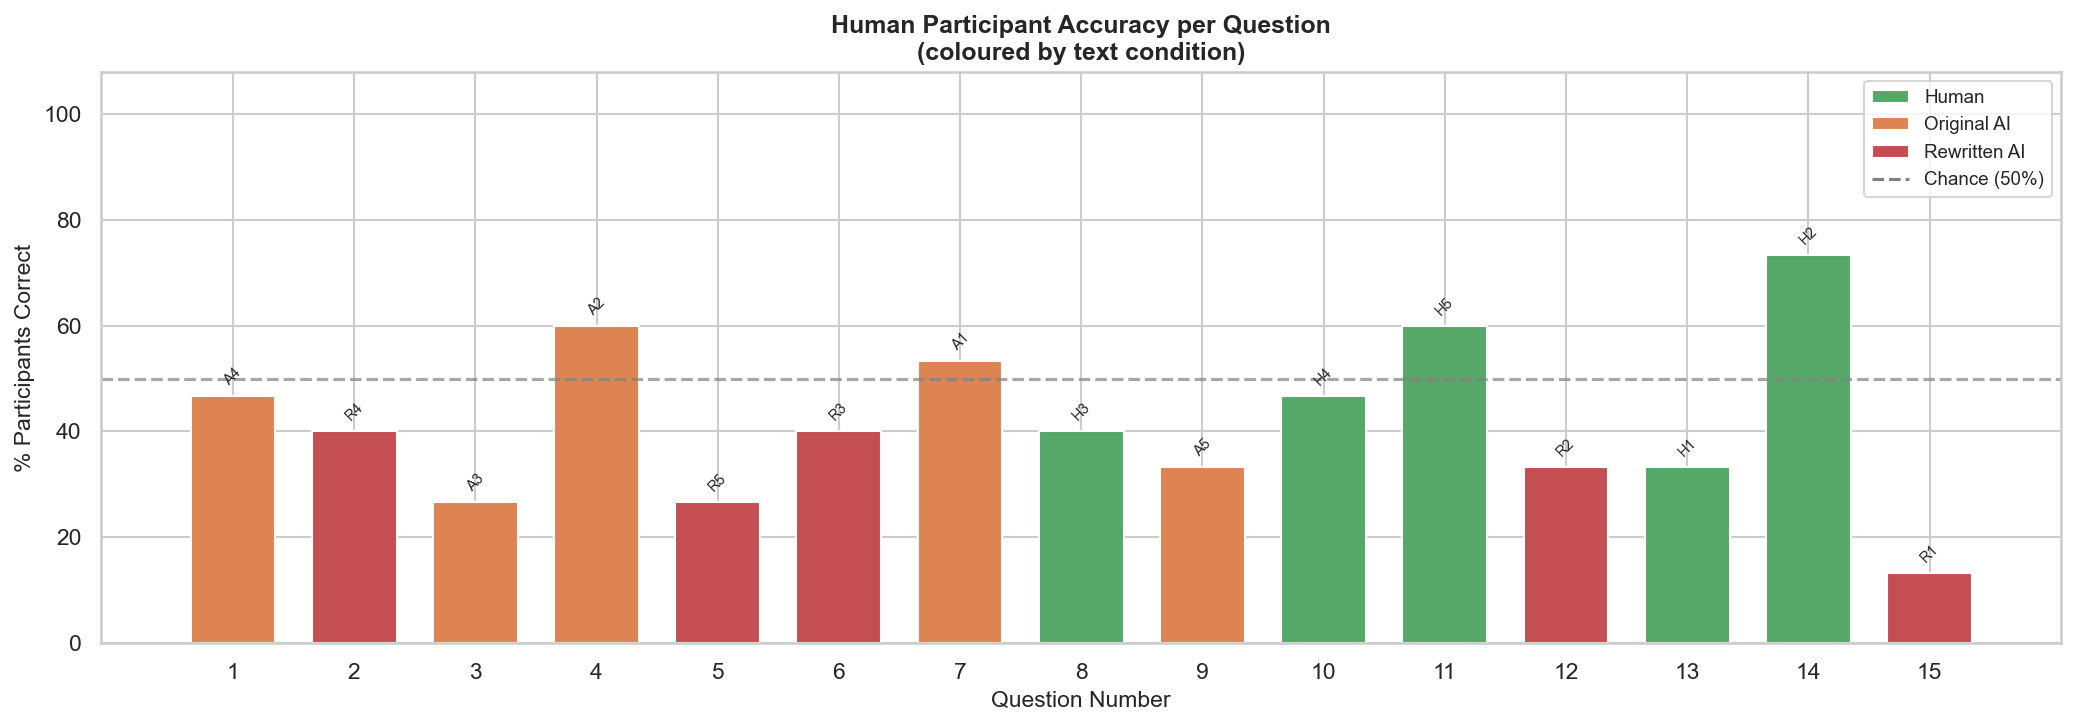

In [6]:
cond_colours = {'Human': '#55A868', 'Original AI': '#DD8452', 'Rewritten AI': '#C44E52'}
plot_df = agg_df.sort_values('question_number')

fig, ax = plt.subplots(figsize=(14, 5))
bar_colours = [cond_colours[c] for c in plot_df['condition']]
bars = ax.bar(plot_df['question_number'], plot_df['accuracy_pct'],
              color=bar_colours, edgecolor='white', width=0.7)

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Chance (50%)')

for bar, sid in zip(bars, plot_df['sample_id']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            sid, ha='center', va='bottom', fontsize=7, rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cond_colours.items()]
legend_elements.append(plt.Line2D([0],[0], color='gray', linestyle='--', label='Chance (50%)'))
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.set_title('Human Participant Accuracy per Question\n(coloured by text condition)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Question Number', fontsize=11)
ax.set_ylabel('% Participants Correct', fontsize=11)
ax.set_xticks(plot_df['question_number'])
ax.set_ylim(0, 108)
plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig12_per_question_accuracy.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure 12 saved: {fig_path}')
plt.show()

## Cell 7 — Human vs RoBERTa Comparison Chart (Figure 13)

> **DISSERTATION NOTE:** This is **Figure 13** in Chapter 5 — the key comparison between human and model detection rates before and after the paraphrase attack.

Figure 13 saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig13_human_vs_roberta.png


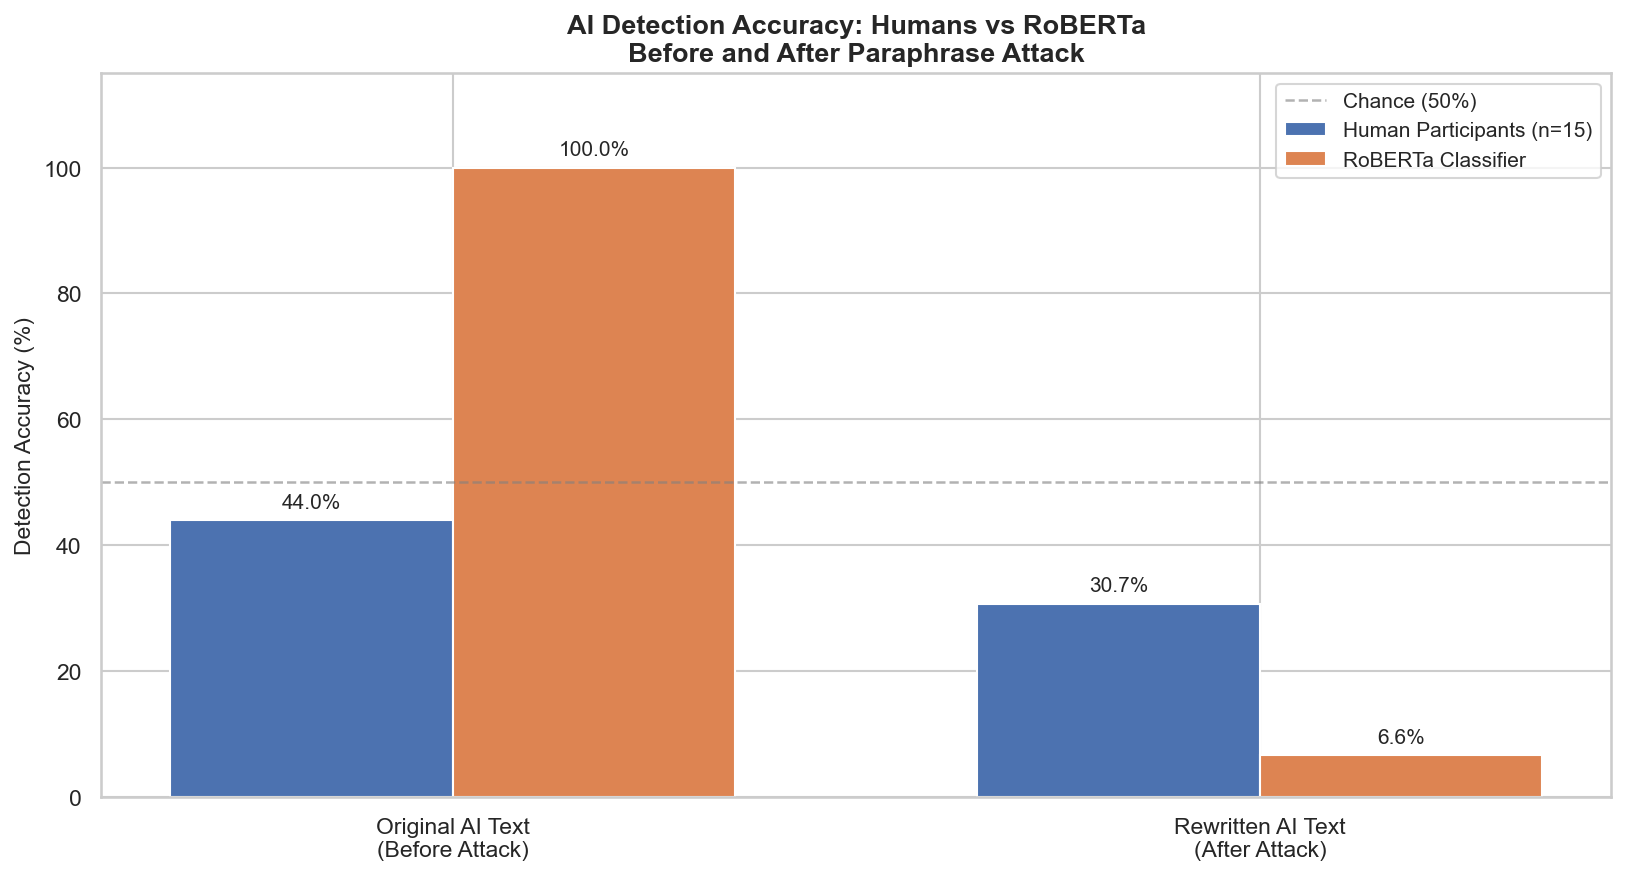


RoBERTa: 100.0% → 6.6% (drop: 93.4pp)
Humans : 44.0% → 30.7% (drop: 13.3pp)


In [7]:
with open(os.path.join(RESULTS_METRICS, 'results_adversarial.json'), 'r') as f:
    adv_results = json.load(f)

roberta_original  = adv_results['original_detection_rate'] * 100   # 100.0%
roberta_rewritten = adv_results['rewritten_detection_rate'] * 100  # 6.6%

fig, ax = plt.subplots(figsize=(11, 6))
x     = np.arange(2)
width = 0.35

b1 = ax.bar(x - width/2, [human_original, human_rewritten], width,
            label='Human Participants (n=15)', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + width/2, [roberta_original, roberta_rewritten], width,
            label='RoBERTa Classifier',        color='#DD8452', edgecolor='white')

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='Chance (50%)')
ax.set_title('AI Detection Accuracy: Humans vs RoBERTa\nBefore and After Paraphrase Attack',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Detection Accuracy (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(['Original AI Text\n(Before Attack)', 'Rewritten AI Text\n(After Attack)'], fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.bar_label(b1, labels=[f'{v:.1f}%' for v in [human_original, human_rewritten]],   padding=4, fontsize=10)
ax.bar_label(b2, labels=[f'{v:.1f}%' for v in [roberta_original, roberta_rewritten]], padding=4, fontsize=10)

plt.tight_layout()
fig_path = os.path.join(RESULTS_FIGS, 'fig13_human_vs_roberta.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure 13 saved: {fig_path}')
plt.show()

print(f'\nRoBERTa: {roberta_original:.1f}% → {roberta_rewritten:.1f}% '
      f'(drop: {roberta_original-roberta_rewritten:.1f}pp)')
print(f'Humans : {human_original:.1f}% → {human_rewritten:.1f}% '
      f'(drop: {human_original-human_rewritten:.1f}pp)')

## Cell 8 — Human Accuracy by Condition Bar Chart (Figure 14)

> **DISSERTATION NOTE:** This is **Figure 14** in Chapter 5.

Figure 14 saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig14_human_accuracy_by_condition.png


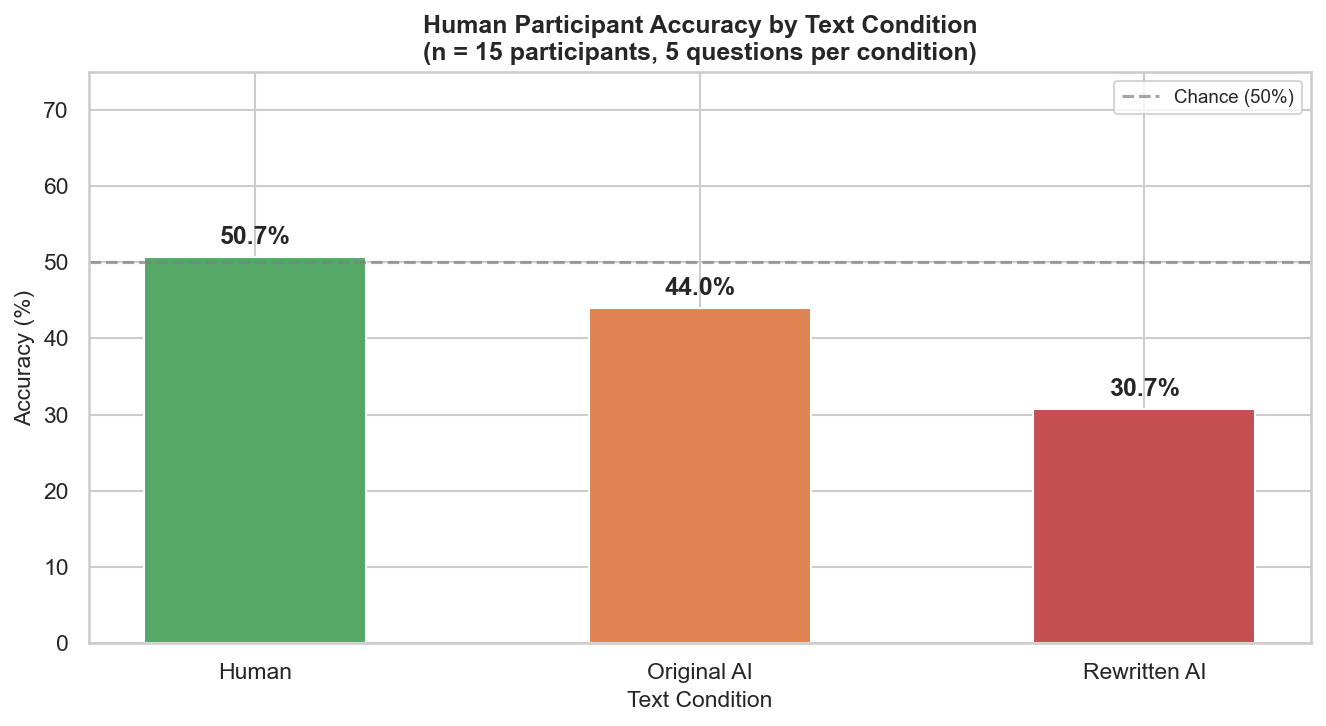

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
cond_order  = ['Human', 'Original AI', 'Rewritten AI']
accuracies  = [float(condition_acc.loc[c, 'Accuracy_%']) for c in cond_order]
bar_colours = ['#55A868', '#DD8452', '#C44E52']

bars = ax.bar(cond_order, accuracies, color=bar_colours, edgecolor='white', width=0.5)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Chance (50%)')
ax.set_title('Human Participant Accuracy by Text Condition\n(n = 15 participants, 5 questions per condition)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xlabel('Text Condition', fontsize=11)
ax.set_ylim(0, 75)
ax.legend(fontsize=9)
ax.bar_label(bars, labels=[f'{a:.1f}%' for a in accuracies], padding=4, fontsize=12, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(RESULTS_FIGS, 'fig14_human_accuracy_by_condition.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure 14 saved: {fig_path}')
plt.show()

## Cell 9 — Save Results (Table 6 + JSON)

> **DISSERTATION NOTE:** Table 6 goes into Chapter 5 (Results).

In [9]:
human_eval_results = {
    'n_participants'              : 15,
    'n_questions'                 : 15,
    'total_judgements'            : 225,
    'overall_accuracy'            : round(overall_acc / 100, 4),
    'human_text_accuracy'         : round(human_baseline  / 100, 4),
    'original_ai_accuracy'        : round(human_original  / 100, 4),
    'rewritten_ai_accuracy'       : round(human_rewritten / 100, 4),
    'roberta_original_detection'  : round(roberta_original  / 100, 4),
    'roberta_rewritten_detection' : round(roberta_rewritten / 100, 4),
}

he_json_path = os.path.join(RESULTS_METRICS, 'results_human_evaluation.json')
with open(he_json_path, 'w') as f:
    json.dump(human_eval_results, f, indent=2)

table_rows = []
for cond in ['Human', 'Original AI', 'Rewritten AI']:
    table_rows.append({
        'Condition'          : cond,
        'Human Accuracy (%)' : float(condition_acc.loc[cond, 'Accuracy_%']),
        'Correct / Total'    : f"{int(condition_acc.loc[cond,'Correct'])} / {int(condition_acc.loc[cond,'Total'])}",
    })
table_rows.append({'Condition': 'OVERALL',
                   'Human Accuracy (%)': round(overall_acc, 1),
                   'Correct / Total': f'{total_correct} / {TOTAL_JUDGEMENTS}'})

table_df = pd.DataFrame(table_rows)
table_path = os.path.join(RESULTS_TABLES, 'table06_human_evaluation.csv')
table_df.to_csv(table_path, index=False)

print('=== TABLE 6: Human Evaluation Results ===')
print(table_df.to_string(index=False))
print(f'\nJSON saved : {he_json_path}')
print(f'CSV  saved : {table_path}')
print()
print(json.dumps(human_eval_results, indent=2))

=== TABLE 6: Human Evaluation Results ===
   Condition  Human Accuracy (%) Correct / Total
       Human                50.7         38 / 75
 Original AI                44.0         33 / 75
Rewritten AI                30.7         23 / 75
     OVERALL                41.8        94 / 225

JSON saved : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\results_human_evaluation.json
CSV  saved : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\tables\table06_human_evaluation.csv

{
  "n_participants": 15,
  "n_questions": 15,
  "total_judgements": 225,
  "overall_accuracy": 0.4178,
  "human_text_accuracy": 0.507,
  "original_ai_accuracy": 0.44,
  "rewritten_ai_accuracy": 0.307,
  "roberta_original_detection": 1.0,
  "roberta_rewritten_detection": 0.066
}


---
## Stage 2 Summary — Real Results (n=15)

| Metric | Value |
|--------|-------|
| Overall human accuracy | **41.8%** (below chance) |
| Human text accuracy | **50.7%** (near chance) |
| Original AI accuracy | **44.0%** |
| Rewritten AI accuracy | **30.7%** (lowest — paraphrase fools humans) |
| RoBERTa on original AI | **100.0%** |
| RoBERTa on rewritten AI | **6.6%** (catastrophic drop) |

**Key dissertation insight:** Paraphrase rewriting attacks are effective against both automated detectors (RoBERTa drops 93.4pp) and human evaluators (accuracy falls to 30.7%, below chance). However, the attack is disproportionately more effective against the trained model than against humans, suggesting that the model learned surface-level stylometric features rather than deep semantic properties of AI-generated text.

**Figures produced:**
- `fig12_per_question_accuracy.png` — per-question breakdown
- `fig13_human_vs_roberta.png` — humans vs model comparison
- `fig14_human_accuracy_by_condition.png` — condition bar chart

**Tables produced:**
- `table06_human_evaluation.csv` — Table 6 in Chapter 5
- `results_human_evaluation.json` — for programmatic access